In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_classification, make_regression 
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor, NearestCentroid
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split 
from scipy.spatial.distance import mahalanobis, hamming
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

**Метод ближайших центроидов**


Точность метода ближайших центроидов: 0.867


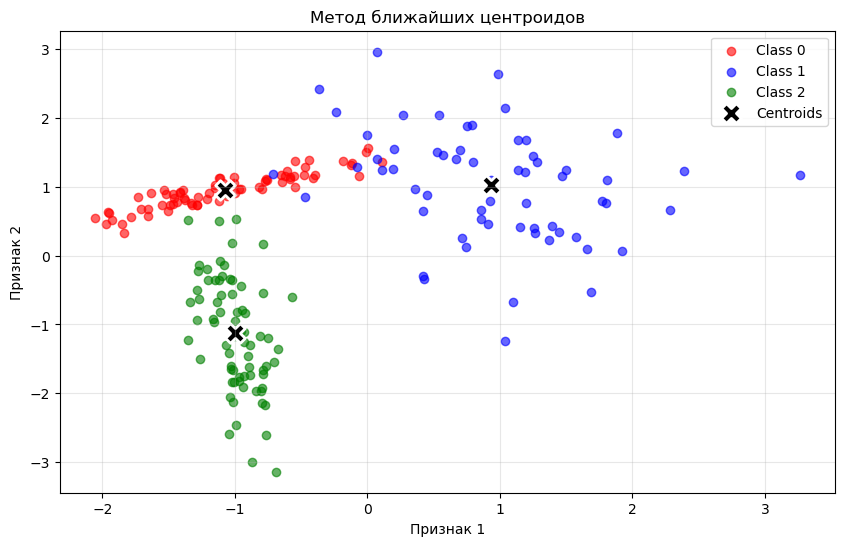

In [3]:
X, y = make_classification(n_samples=300, n_features=2, n_redundant=0, 
                           n_clusters_per_class=1, n_classes=3, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

centroid_model = NearestCentroid()
centroid_model.fit(X_train, y_train)

y_pred = centroid_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Точность метода ближайших центроидов: {accuracy:.3f}')

plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green'] 

for i, color in enumerate(colors):
    plt.scatter(X_train[y_train == i, 0], X_train[y_train == i, 1], 
                c=color, label=f'Class {i}', alpha=0.6)

plt.scatter(centroid_model.centroids_[:, 0], centroid_model.centroids_[:, 1], 
            marker='X', s=200, c='black', label='Centroids', edgecolors='white', linewidths=2)

plt.title('Метод ближайших центроидов')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
    

**Метод K ближайших соседей (классификация)**

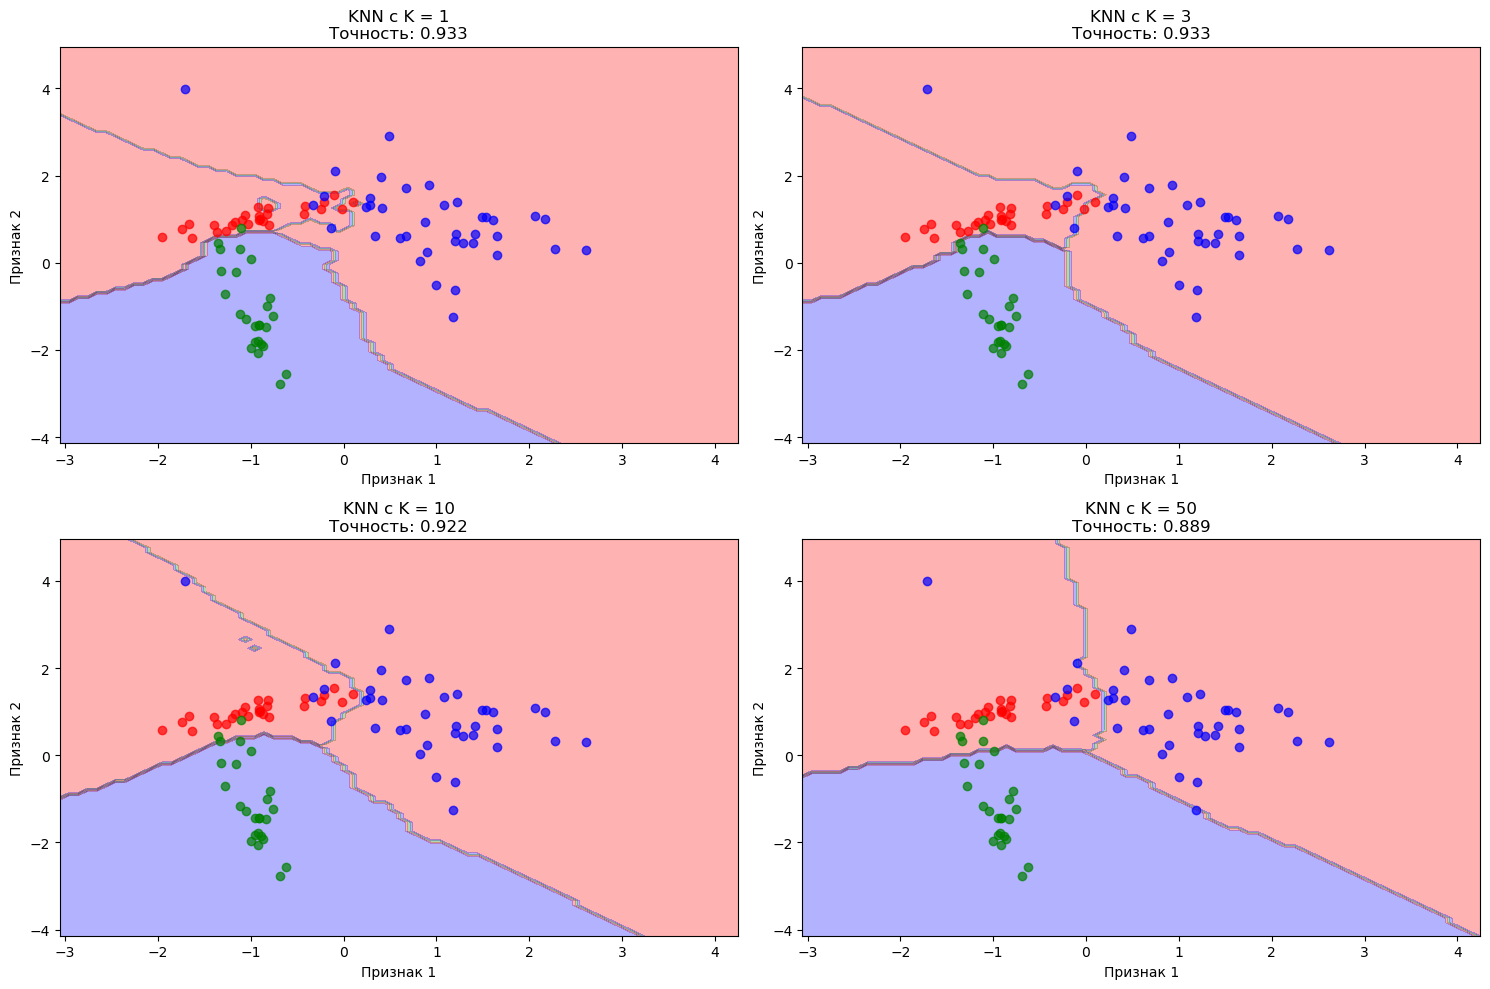

In [32]:
k_value = [1,3,10,50]

plt.figure(figsize = (15,10))

for i , k in enumerate(k_value, 1): 
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    plt.subplot(2,2,i)

    x_min, x_max = X[: , 0].min() - 1 , X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), 
    np.arange(y_min, y_max , 0.1))

    Z = knn.predict(np.c_[xx.ravel() , yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx ,yy, Z , alpha = 0.3, colors = colors)
    for j , color in enumerate(colors): 
        plt.scatter(X_test[y_test == j, 0] , X_test[y_test == j, 1], c = color, label = f'Class {j}', alpha = 0.7) 
        
        plt.title(f'KNN c K = {k}\nТочность: {accuracy:.3f}')
        plt.xlabel('Признак 1')
        plt.ylabel('Признак 2')

plt.tight_layout()
plt.show()



**Метод K ближайших соседей для регрессии**

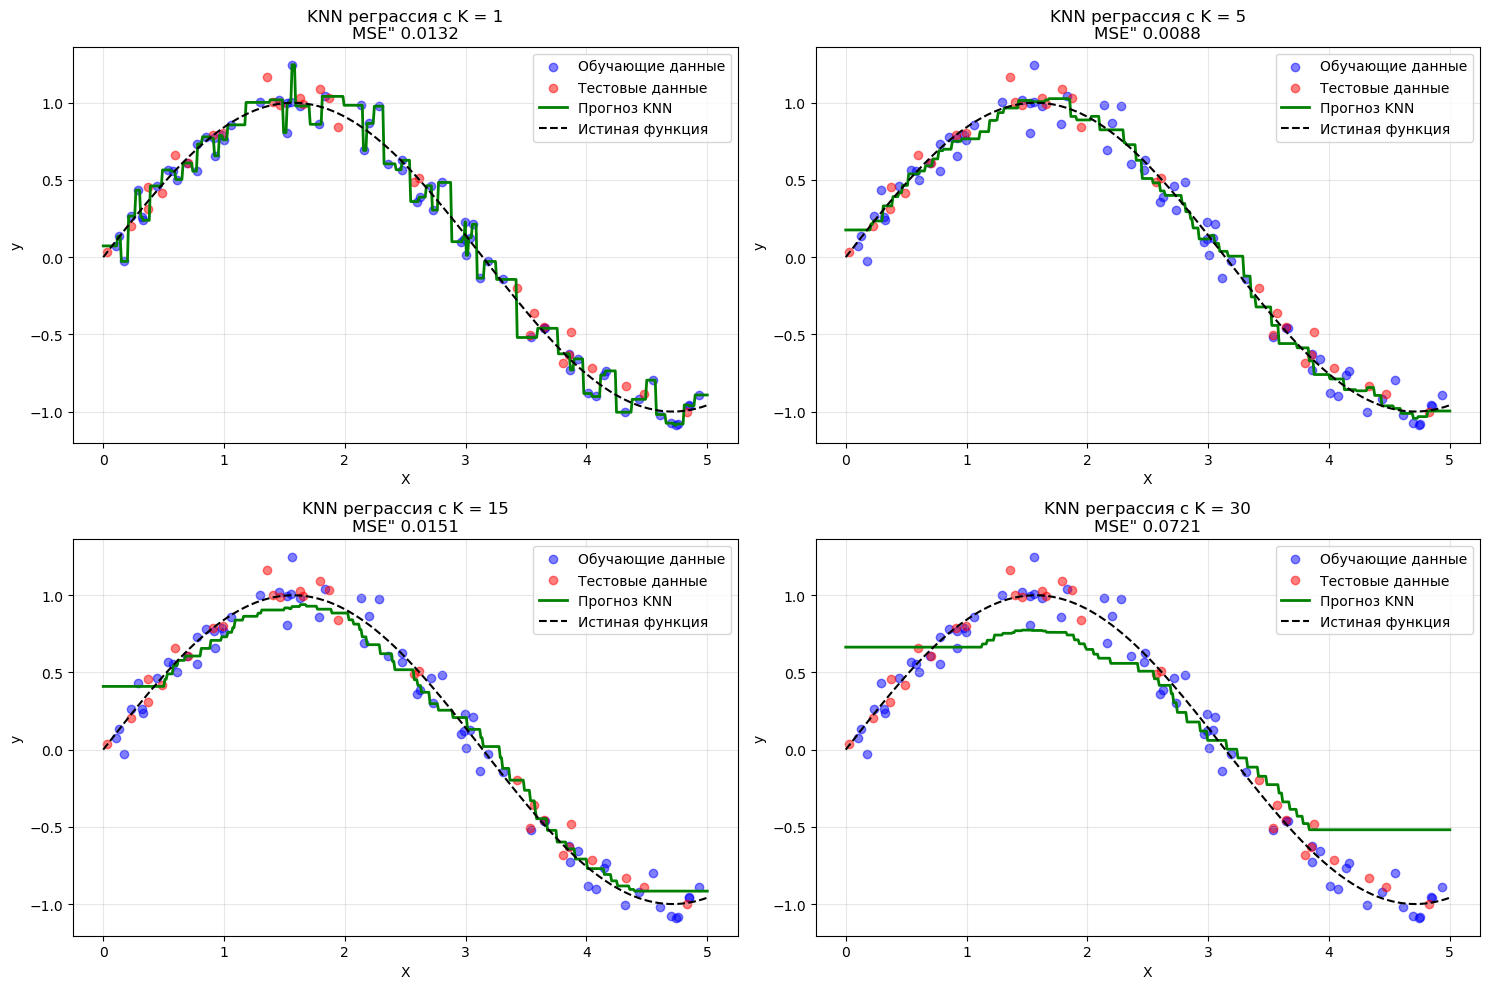

In [22]:
np.random.seed(42)

X_reg = np.sort( 5 * np.random.rand(100,1), axis = 0)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.1, X_reg.shape[0])


X_train_reg, X_test_reg, y_train_reg , y_test_reg = train_test_split( X_reg, y_reg, test_size = 0.3 , random_state = 42)

k_value_reg = [1,5 ,15,30]
plt.figure(figsize = (15,10))

for i , k in enumerate( k_value_reg, 1):
    plt.subplot(2,2,i)

    knn_reg = KNeighborsRegressor(n_neighbors=k)
    knn_reg.fit(X_train_reg, y_train_reg)

    X_plot = np.linspace(0, 5 , 500).reshape(-1, 1)
    y_plot = knn_reg.predict(X_plot)

    y_pred_reg = knn_reg.predict(X_test_reg)

    mse = mean_squared_error(y_test_reg, y_pred_reg)


    plt.scatter(X_train_reg , y_train_reg, c = 'blue', label = 'Обучающие данные' , alpha = 0.5)
    plt.scatter(X_test_reg , y_test_reg , c = 'red', label = 'Тестовые данные' , alpha = 0.5) 
    plt.plot(X_plot, y_plot , c ='green' , linewidth = 2 , label ='Прогноз KNN')
    plt.plot(X_plot, np.sin(X_plot) , '--' , c= 'black' , label ='Истиная функция') 


    plt.title(f'KNN реграссия с K = {k}\nMSE" {mse:.4f}')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()



**Взвешенный KNN**

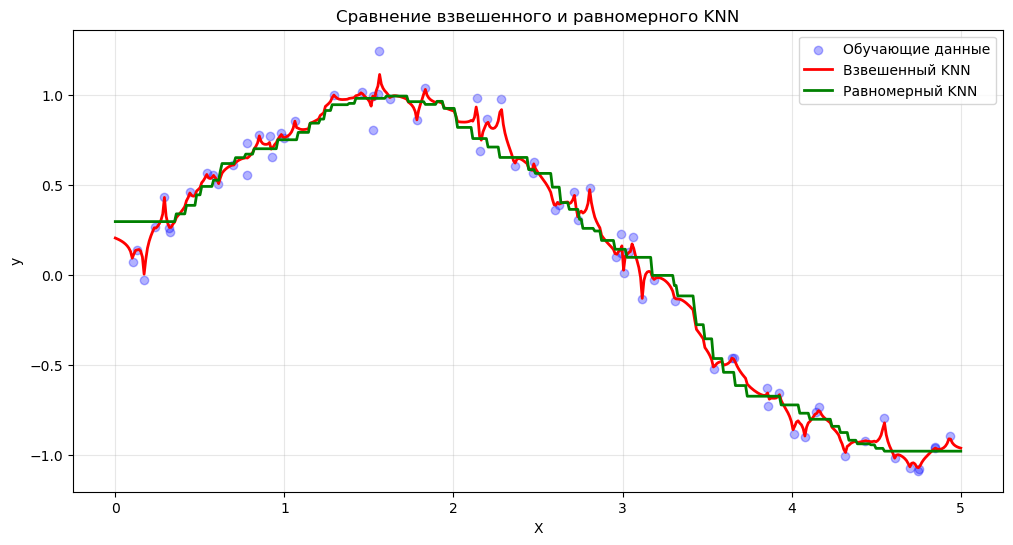

MSE взвешенного KNN: 0.0082
MSE равномерного KNN: 0.0100


In [29]:
knn_weighted = KNeighborsRegressor(n_neighbors = 10, weights = 'distance')
knn_weighted.fit(X_train_reg, y_train_reg)

knn_uniform = KNeighborsRegressor(n_neighbors = 10, weights= 'uniform')
knn_uniform.fit(X_train_reg , y_train_reg)

X_plot= np.linspace(0,5, 500).reshape(-1,1)
y_plot_weighted = knn_weighted.predict(X_plot)
y_plot_uniform = knn_uniform.predict(X_plot)

plt.figure(figsize = (12,6))
plt.scatter(X_train_reg, y_train_reg , c= 'blue' , label ='Обучающие данные' , alpha = 0.3)
plt.plot(X_plot, y_plot_weighted, c = 'red' , linewidth = 2 , label = 'Взвешенный KNN')
plt.plot(X_plot, y_plot_uniform , c = 'green' , linewidth = 2, label = 'Равномерный KNN')

plt.title('Сравнение взвешенного и равномерного KNN')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha =0.3)
plt.show()


y_pred_weighted = knn_weighted.predict(X_test_reg)
y_pred_uniform = knn_uniform.predict(X_test_reg)


mse_weight = mean_squared_error(y_test_reg , y_pred_weighted)
mse_uniform = mean_squared_error(y_test_reg , y_pred_uniform) 

print(f'MSE взвешенного KNN: {mse_weight:.4f}')
print(f'MSE равномерного KNN: {mse_uniform:.4f}')


**Классификация с учетов корреляции**


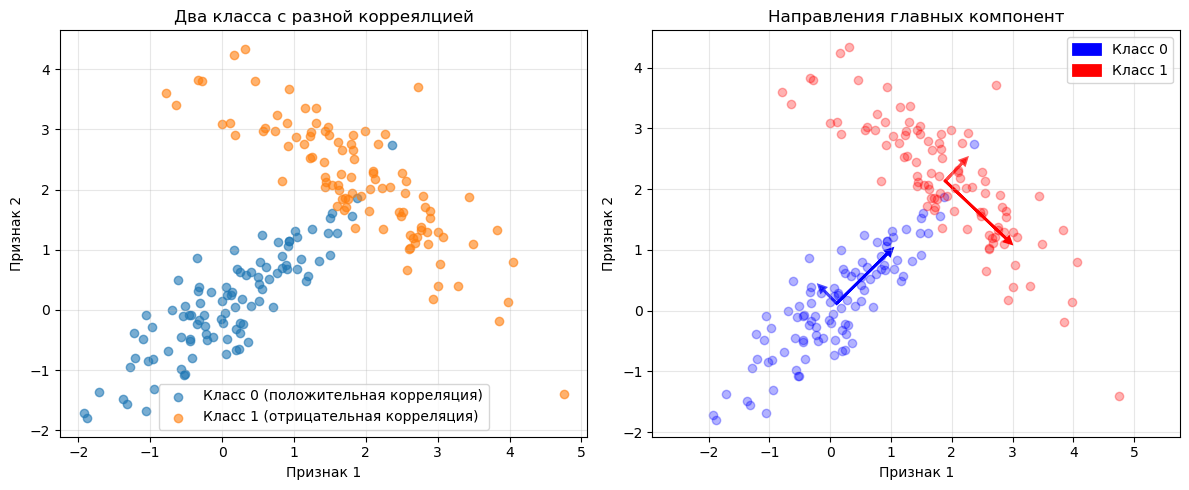

Вывод: Расстояние Махаланобиса учитывает форму распределения каждого класса
Класс 0: положительная корреляция (стрелки в одном направлении)
Класс 1: отрицательная корреляция (стрелки в разных направлениях)


In [44]:
np.random.seed(42)

class0 = np.random.multivariate_normal([0,0],[[1, 0.9] , [0.9, 1]] , 100)

class1 =np.random.multivariate_normal([2,2] , [[1, -0.8] , [-0.8 , 1]] , 100)

X_classes = np.vstack([class0 , class1])
y_classes = np.array([0] * 100 + [1] * 100) 

plt.figure(figsize = (12,5))

plt.subplot(1,2,1)
plt.scatter(class0[: , 0], class0[:, 1] ,alpha = 0.6, label = 'Класс 0 (положительная корреляция)')
plt.scatter(class1[: , 0] , class1[:, 1] , alpha = 0.6, label = 'Класс 1 (отрицательная корреляция)')
plt.title('Два класса с разной корреялцией') 
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True, alpha = 0.3)
plt.legend()

plt.subplot(1,2,2)

def plot_principal_components(ax, data , color, label):
    cov = np.cov(data.T)
    eigenvals, eigenvecs = np.linalg.eig(cov)
    mean = np.mean(data, axis = 0)


    pc1 = eigenvecs[:, 0] * np.sqrt(eigenvals[0])
    ax.arrow(mean[0], mean[1], pc1[0], pc1[1], head_width=0.1, head_length=0.1,
             fc=color, ec=color, linewidth=2, label=label)

    pc2 = eigenvecs[:, 1] * np.sqrt(eigenvals[1])
    ax.arrow(mean[0], mean[1], pc2[0], pc2[1], head_width=0.1, head_length=0.1,
             fc=color, ec=color, linewidth=2, alpha=0.7)


plt.scatter(class0[:, 0], class0[:, 1], alpha=0.3, c='blue')
plt.scatter(class1[:, 0], class1[:, 1], alpha=0.3, c='red')
plot_principal_components(plt.gca(), class0, 'blue', 'Класс 0')
plot_principal_components(plt.gca(), class1, 'red', 'Класс 1')
plt.title('Направления главных компонент')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
                 
plt.tight_layout()
plt.show()
             
print("Вывод: Расстояние Махаланобиса учитывает форму распределения каждого класса")
print("Класс 0: положительная корреляция (стрелки в одном направлении)")
print("Класс 1: отрицательная корреляция (стрелки в разных направлениях)")

**Локально-постоянная регрессия (Надарая-Ватсона)**

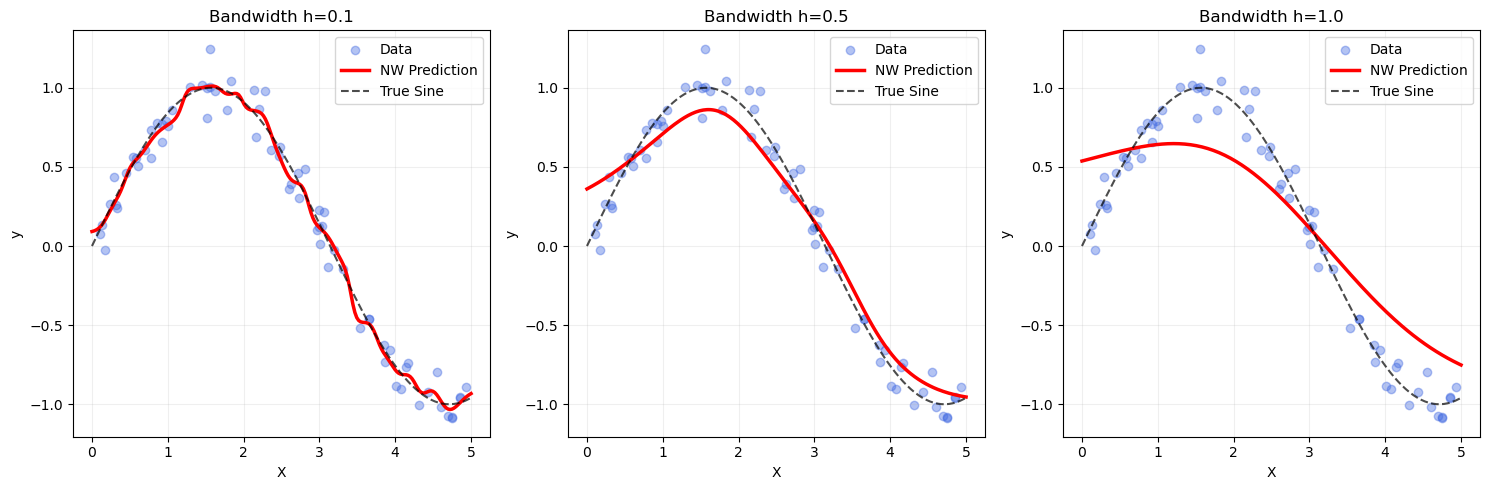

In [46]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_kernel(u):
    return np.exp(-0.5 * u**2)

def epanechnikov_kernel(u):
    return np.maximum(0, 1 - u**2)

def nadaraya_watson_regression(X_train, y_train, X_test, h, kernel='gaussian'):
    u = (X_test[:, np.newaxis] - X_train) / h
    
    kernels = {
        'gaussian': gaussian_kernel,
        'epanechnikov': epanechnikov_kernel
    }
    weights = kernels[kernel](u)
    
    numerator = np.sum(weights * y_train, axis=1)
    denominator = np.sum(weights, axis=1)
    
    return np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator != 0)

bandwidths = [0.1, 0.5, 1.0]
X_plot = np.linspace(0, 5, 200)

plt.figure(figsize=(15, 5))

for i, h in enumerate(bandwidths, 1):
    plt.subplot(1, 3, i)
    
    y_plot_nw = nadaraya_watson_regression(
        X_train_reg.ravel(), 
        y_train_reg, 
        X_plot, 
        h, 
        kernel='gaussian'
    )
    
    plt.scatter(X_train_reg, y_train_reg, c='royalblue', alpha=0.4, label='Data')
    plt.plot(X_plot, y_plot_nw, c='red', linewidth=2.5, label='NW Prediction')
    plt.plot(X_plot, np.sin(X_plot), '--', c='black', alpha=0.7, label='True Sine')
    
    plt.title(f'Bandwidth h={h}')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

**KNN на Iris dataset**

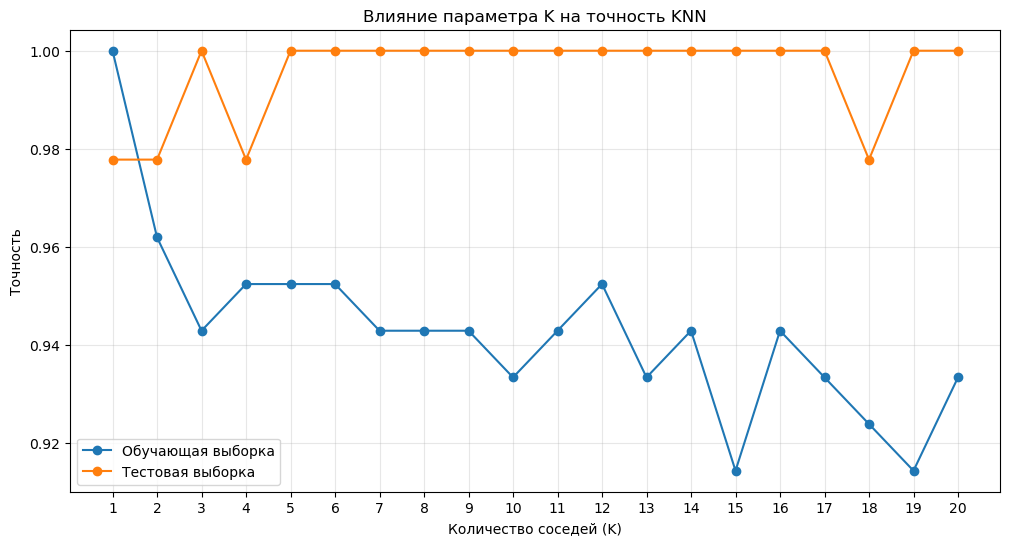

Оптимальное количество соседей: 3
Максимальная точность на тестовой выборке: 1.000


In [56]:

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler



iris = load_iris()
X_iris, y_iris = iris.data, iris.target


scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris_scaled, y_iris, test_size=0.3, random_state=42)

k_range = range(1, 21)
train_scores = []
test_scores = []

for k in k_range:
    knn_iris = KNeighborsClassifier(n_neighbors=k)
    knn_iris.fit(X_train_iris, y_train_iris)
    
    train_scores.append(knn_iris.score(X_train_iris, y_train_iris))
    test_scores.append(knn_iris.score(X_test_iris, y_test_iris))

plt.figure(figsize=(12, 6))
plt.plot(k_range, train_scores, 'o-', label='Обучающая выборка')
plt.plot(k_range, test_scores, 'o-', label='Тестовая выборка')
plt.xlabel('Количество соседей (K)')
plt.ylabel('Точность')
plt.title('Влияние параметра K на точность KNN')
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

optimal_k = k_range[np.argmax(test_scores)]
print(f"Оптимальное количество соседей: {optimal_k}")
print(f"Максимальная точность на тестовой выборке: {max(test_scores):.3f}")